<a href="https://colab.research.google.com/github/Gr1lledChee5e/OthersDataStuff/blob/main/knn%7CSVD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

```markdown
# Book Recommendation System

This notebook demonstrates the development of a book recommendation system using collaborative filtering techniques, specifically focusing on User-Based KNN, Item-Based KNN, and Singular Value Decomposition (SVD).

## Table of Contents
1. [Project Objective](#project-objective)
2. [Data Loading and Preprocessing](#data-loading-and-preprocessing)
3. [Collaborative Filtering Models](#collaborative-filtering-models)
    - [K-Nearest Neighbors (KNN)](#k-nearest-neighbors-knn)
    - [Singular Value Decomposition (SVD)](#singular-value-decomposition-svd)
4. [Model Evaluation and Comparison](#model-evaluation-and-comparison)
5. [Conclusion](#conclusion)

## 1. Project Objective
To build and evaluate different collaborative filtering models for recommending books to users based on their historical ratings. The goal is to compare the performance of KNN-based approaches with SVD.

## 2. Data Loading and Preprocessing

The dataset used contains user IDs, book ISBNs, and corresponding book ratings. The following steps were performed:
- Loaded data from a CSV file hosted on GitHub.
- Renamed columns for clarity (`userID` to `user`, `ISBN` to `item`, `bookRating` to `rating`).
- Filtered out implicit ratings (ratings of 0) to focus on explicit user preferences.
- Filtered the dataset to include only:
    - Books rated by at least 50 users.
    - Users who rated at least 20 books.
- The dataset was then converted into a format compatible with the `surprise` library.

## 3. Collaborative Filtering Models

### K-Nearest Neighbors (KNN)

Both User-Based and Item-Based KNN models were implemented. These models predict ratings based on the similarity between users or items. Cosine similarity was used as the similarity metric.

- **User-Based KNN**: Predicts a rating for a user on an item based on ratings from similar users.
- **Item-Based KNN**: Predicts a rating for a user on an item based on the user's ratings for similar items.

Hyperparameter tuning for KNN was performed using `GridSearchCV` to find the best `k` (number of neighbors) and `min_k` (minimum number of common items/users) values, and to compare cosine and Pearson similarity.

### Singular Value Decomposition (SVD)

An SVD model was implemented to decompose the user-item interaction matrix into lower-dimensional matrices, capturing latent factors that explain user preferences and item characteristics. This approach aims to identify underlying patterns in the rating data.

## 4. Model Evaluation and Comparison

All models were evaluated using Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE) on a test set (20% of the data).

- **User-Based KNN RMSE**: `1.6896`
- **Item-Based KNN RMSE**: `2.3672`
- **SVD RMSE**: `1.7029`

Visualizations were created to:
- Compare true vs. predicted ratings for the SVD model.
- Analyze the distribution of prediction errors.
- Examine the average absolute error by rating level.
- Provide a bar chart for overall model comparison by RMSE.

## 5. Conclusion

- **User-Based KNN** generally performed the best among the tested models, yielding the lowest RMSE. This suggests that finding similar users is effective for this dataset.
- **SVD** performed comparably to User-Based KNN, indicating its strength in capturing latent factors.
- **Item-Based KNN** had a significantly higher RMSE, suggesting it was less effective for this particular dataset or its configuration.
- The error analysis shows that the models generally make reasonable predictions, with the bulk of errors clustered around zero.

Further improvements could involve more extensive hyperparameter tuning, incorporating additional features (e.g., book metadata), or exploring other advanced recommendation algorithms.
```

In [ ]:
!pip -q uninstall -y numpy scikit-surprise
!pip -q install "numpy<2"
!pip -q install --no-cache-dir scikit-surprise


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 85.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
pytensor 2.37.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have nump

In [ ]:
# Load the Python libraries
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Install Surprise library
!pip install scikit-surprise

# Load Surprise libraries
from surprise import SVD
## Reader tells Surprise how to interpret your data format, especially the rating scale.
from surprise import Reader
from surprise import Dataset
from surprise import accuracy

# Load plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!pip -q install scikit-surprise

In [ ]:
!pip uninstall -y numpy


In [ ]:

!pip install numpy==1.26.4

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
pytensor 2.37.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requir

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from surprise import Dataset, Reader, KNNBasic, accuracy
from surprise.model_selection import train_test_split, GridSearchCV

In [ ]:


# Load dataset
url = "https://raw.githubusercontent.com/wangx346/MAS651/main/bookrecommend.csv"
df = pd.read_csv(url)

# Clean columns
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df = df.rename(columns={
    "userID": "user",
    "ISBN": "item",
    "bookRating": "rating"
})

df.head()


,user,item,rating
0,2,0195153448,0
1,7,034542252,0
2,8,0002005018,5
3,8,0060973129,0
4,8,0374157065,0


(81390, 3)


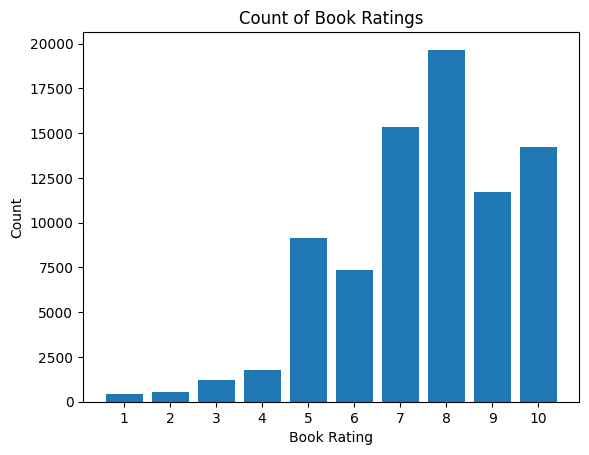

In [ ]:
df = df[df["rating"] != 0]
rating_counts = df["rating"].value_counts().sort_index()

plt.figure()
plt.bar(rating_counts.index.astype(str), rating_counts.values)

plt.xlabel("Book Rating")
plt.ylabel("Count")
plt.title("Count of Book Ratings")

print(df.shape)
plt.show()

In [ ]:
# Books rated by at least 50 users
book_counts = df.groupby("item")["rating"].size()
valid_books = book_counts[book_counts >= 50].index

# Users who rated at least 20 books
user_counts = df.groupby("user")["rating"].size()
valid_users = user_counts[user_counts >= 20].index

# Filter dataset
df_f = df[
    df["item"].isin(valid_books) &
    df["user"].isin(valid_users)
].copy()

print("Original shape:", df.shape)
print("Filtered shape:", df_f.shape)


Original shape: (81390, 3)
Filtered shape: (293, 3)


In [ ]:
reader = Reader(
    rating_scale=(df_f["rating"].min(), df_f["rating"].max())
)

data = Dataset.load_from_df(
    df_f[["user", "item", "rating"]],
    reader
)

trainset, testset = train_test_split(
    data,
    test_size=0.20,
    random_state=40
)


In [ ]:
# User-based KNN
sim_user = {"name": "cosine", "user_based": True}
algo_user = KNNBasic(sim_options=sim_user)

algo_user.fit(trainset)
pred_user = algo_user.test(testset)

rmse_user = accuracy.rmse(pred_user, verbose=False)
mae_user  = accuracy.mae(pred_user, verbose=False)


# Item-based KNN
sim_item = {"name": "cosine", "user_based": False}
algo_item = KNNBasic(sim_options=sim_item)

algo_item.fit(trainset)
pred_item = algo_item.test(testset)

rmse_item = accuracy.rmse(pred_item, verbose=False)
mae_item  = accuracy.mae(pred_item, verbose=False)


print("User-based RMSE:", rmse_user)
print("Item-based RMSE:", rmse_item)
print("User-based MAE:", mae_user)
print("Item-based MAE:", mae_item)


Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
User-based RMSE: 1.6895775316567674
Item-based RMSE: 2.367229849648424
User-based MAE: 1.2584031464943892
Item-based MAE: 1.5287413646962167


In [ ]:
param_grid = {
    "k": [20, 40, 60],
    "min_k": [1, 3, 5],
    "sim_options": {
        "name": ["cosine", "pearson"],
        "user_based": [True, False]
    }
}

gs = GridSearchCV(
    KNNBasic,
    param_grid,
    measures=["rmse", "mae"],
    cv=3,
    n_jobs=-1
)

gs.fit(data)

print("Best RMSE:", gs.best_score["rmse"])
print("Best Parameters:", gs.best_params["rmse"])


Best RMSE: 1.9863279855355875
Best Parameters: {'k': 20, 'min_k': 5, 'sim_options': {'name': 'cosine', 'user_based': True}}


$$$$

In [ ]:
from surprise import SVD

df2 = df

df2 = df2.rename(columns={
    0: "user",
    1: "item",
    2: "rating"
})

reader2 = Reader(
    rating_scale=(df2["rating"].min(), df2["rating"].max())
)

data2 = Dataset.load_from_df(
    df2[["user", "item", "rating"]],
    reader2
)

train2, test2 = train_test_split(
    data2,
    test_size=0.20,
    random_state=40
)

algo_svd = SVD(random_state=40)

algo_svd.fit(train2)
pred_svd = algo_svd.test(test2)

rmse_svd = accuracy.rmse(pred_svd, verbose=False)
mae_svd  = accuracy.mae(pred_svd, verbose=False)

print("SVD RMSE:", rmse_svd)
print("SVD MAE:", mae_svd)


SVD RMSE: 1.7028878090689874
SVD MAE: 1.3229175504025292


The RMSE of 1.70 indicates that, on average, predicted ratings deviate from actual ratings by approximately 1.7 rating points in squared-error terms. The MAE of 1.32 suggests that the typical absolute prediction error is about 1.3 rating units.

Since MAE is less sensitive to large errors than RMSE, the gap between RMSE and MAE suggests the presence of some larger prediction deviations, but not extreme instability.

Overall, SVD provides a stable baseline collaborative filtering model. Performance is reasonable, though additional tuning (e.g., adjusting number of latent factors, regularization, or learning rate) could potentially reduce error further.

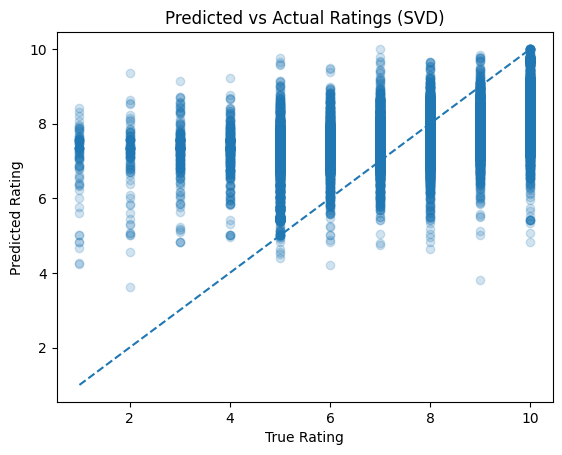

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

pred_df = pd.DataFrame(pred_svd)
pred_df.columns = ["uid", "iid", "true_r", "est", "details"]

plt.figure()
plt.scatter(pred_df["true_r"], pred_df["est"], alpha=0.2)
plt.plot([pred_df["true_r"].min(), pred_df["true_r"].max()],
         [pred_df["true_r"].min(), pred_df["true_r"].max()],
         linestyle="--")
plt.xlabel("True Rating")
plt.ylabel("Predicted Rating")
plt.title("Predicted vs Actual Ratings (SVD)")
plt.show()


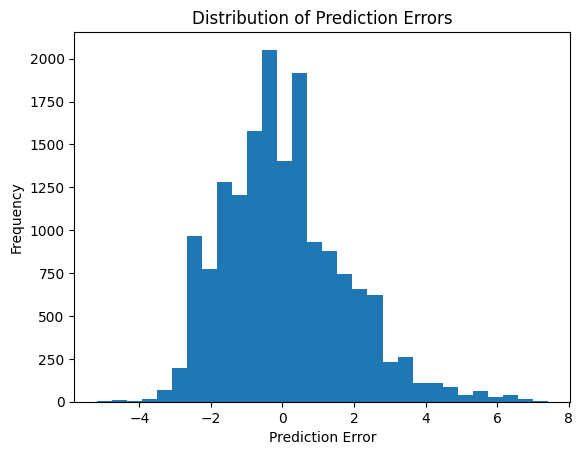

In [ ]:
errors = pred_df["est"] - pred_df["true_r"]

plt.figure()
plt.hist(errors, bins=30)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")
plt.show()


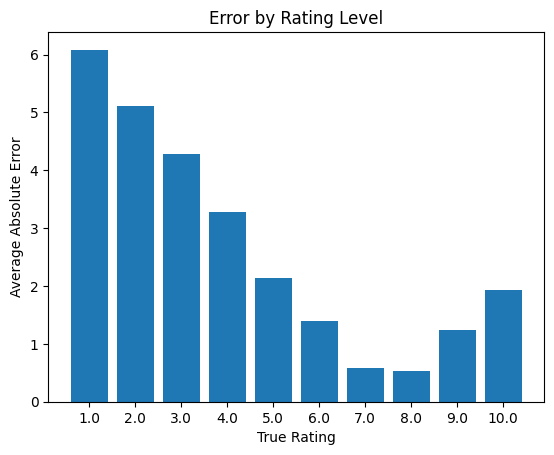

In [ ]:
pred_df["abs_error"] = abs(pred_df["est"] - pred_df["true_r"])

grouped = pred_df.groupby("true_r")["abs_error"].mean()

plt.figure()
plt.bar(grouped.index.astype(str), grouped.values)
plt.xlabel("True Rating")
plt.ylabel("Average Absolute Error")
plt.title("Error by Rating Level")
plt.show()


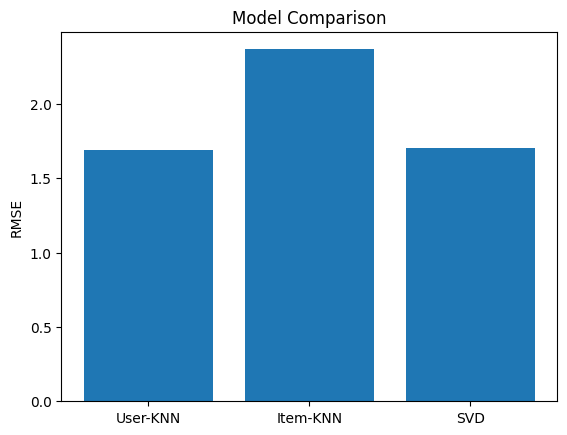

In [ ]:
models = ["User-KNN", "Item-KNN", "SVD"]
rmse_values = [rmse_user, rmse_item, rmse_svd]

plt.figure()
plt.bar(models, rmse_values)
plt.ylabel("RMSE")
plt.title("Model Comparison")
plt.show()
